# TA-005E — Optimización de Hiperparámetros con Optuna

**Objetivo:** Encontrar los hiperparámetros óptimos para EfficientNet-B0 y DenseNet-121 usando Optuna con augmentation v2 (rotación completa, zoom, flip, colorjitter).

**Modelos:** EfficientNet-B0 · DenseNet-121  
**Dataset:** `train_augmented.csv` (6,206 imgs) — subset 35% por trial  
**Métrica objetivo:** AUC macro en validación  
**Trials:** 25 por modelo  
**Referencia actual:** DenseNet AUC=0.8902 · EfficientNet AUC=0.8862

## 1. Instalación

In [ ]:
# !pip install optuna

## 2. Imports

In [1]:
import json
import gc
import time
import numpy as np
import pandas as pd
import pydicom
import optuna
import wandb
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import optuna.visualization as ov
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from pathlib import Path
from sklearn.metrics import roc_auc_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce RTX 4060


## 3. Configuración

In [2]:
BASE          = Path(r'E:\Taller Integrador I\ModelosIA\Radiografias')
MANIFESTS     = BASE / 'dataset_split' / 'manifests'
TRAIN_DIR     = BASE / 'dataset_split' / 'train'
VAL_DIR       = BASE / 'dataset_split' / 'val'
NOTEBOOKS_DIR = Path(r'E:\Taller Integrador I\ModelosIA\modelos\Notebooks')

CLASSES       = ['alveolar_pattern', 'bronchial_pattern', 'pleural_effusion', 'cardiomegaly', 'no_finding']
NUM_CLASSES   = len(CLASSES)
SEED          = 42
IMG_SIZE      = 224
N_TRIALS      = 25
FE_EPOCHS     = 3
MAX_FT_EPOCHS = 20
PRUNER_WARMUP = 4
OPTUNA_SUBSET = 0.35

WANDB_PROJECT = 'vetxray-cnn'
WANDB_ENTITY  = 'dbaylont1-antenor-orrego-private-university'

torch.manual_seed(SEED)
np.random.seed(SEED)
print('Config OK')
print(f'Subset Optuna: {OPTUNA_SUBSET*100:.0f}% ({int(6206*OPTUNA_SUBSET)} imgs por trial)')

Config OK
Subset Optuna: 35% (2172 imgs por trial)


## 4. Transforms v2

In [3]:
TRANSFORM_TRAIN_V2 = transforms.Compose([
    transforms.RandomRotation(degrees=180),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

TRANSFORM_VAL = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print('Transforms v2:')
print('  Train: Rotation±180 | HFlip | VFlip | RandomResizedCrop(0.7-1.0) | ColorJitter')
print('  Val  : Resize + Normalize')

Transforms v2:
  Train: Rotation±180 | HFlip | VFlip | RandomResizedCrop(0.7-1.0) | ColorJitter
  Val  : Resize + Normalize


## 5. Dataset y DataLoaders

In [4]:
class VetXRayDataset(Dataset):
    def __init__(self, df, transform, base_dir):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.base_dir  = base_dir
        self.labels    = self._build_labels()

    def _build_labels(self):
        labels = np.zeros((len(self.df), NUM_CLASSES), dtype=np.float32)
        for i, row in self.df.iterrows():
            for j, cls in enumerate(CLASSES):
                if isinstance(row['TAG'], str) and cls in row['TAG']:
                    labels[i, j] = 1.0
        return labels

    def _load_dicom(self, path):
        dcm = pydicom.dcmread(str(path))
        arr = dcm.pixel_array.astype(np.float32)
        if hasattr(dcm, 'PhotometricInterpretation') and dcm.PhotometricInterpretation == 'MONOCHROME1':
            arr = arr.max() - arr
        p2, p98 = np.percentile(arr, 2), np.percentile(arr, 98)
        arr = np.clip(arr, p2, p98)
        arr = (arr - p2) / (p98 - p2 + 1e-8)
        img = Image.fromarray((arr * 255).astype(np.uint8)).resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
        return Image.merge('RGB', [img, img, img])

    def _load_png(self, path):
        img = Image.open(path).convert('L').resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
        return Image.merge('RGB', [img, img, img])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        if row.get('is_synthetic', False) and pd.notna(row.get('synthetic_path')):
            img = self._load_png(row['synthetic_path'])
        else:
            img = self._load_dicom(self.base_dir / row['FileName'])
        return self.transform(img), torch.tensor(self.labels[idx], dtype=torch.float32)

print('VetXRayDataset OK')

VetXRayDataset OK


In [5]:
df_train = pd.read_csv(MANIFESTS / 'train_augmented.csv')
df_val   = pd.read_csv(MANIFESTS / 'val.csv')

print(f'Train: {len(df_train)} | Val: {len(df_val)}')

pos_counts    = np.array([df_train['TAG'].str.contains(c, na=False).sum() for c in CLASSES], dtype=np.float32)
neg_counts    = len(df_train) - pos_counts
CLASS_WEIGHTS = torch.tensor(neg_counts / (pos_counts + 1e-8), dtype=torch.float32).to(DEVICE)

print('\nClass weights:')
for c, w in zip(CLASSES, CLASS_WEIGHTS.cpu()):
    print(f'  {c:<22}: {w:.3f}')

def get_loaders(batch_size: int, subset: float = OPTUNA_SUBSET):
    df_sub   = df_train.sample(frac=subset, random_state=SEED).reset_index(drop=True)
    train_ds = VetXRayDataset(df_sub,  TRANSFORM_TRAIN_V2, TRAIN_DIR)
    val_ds   = VetXRayDataset(df_val,  TRANSFORM_VAL,      VAL_DIR)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    return train_loader, val_loader

print(f'\nget_loaders() OK — subset: {OPTUNA_SUBSET*100:.0f}% ({int(len(df_train)*OPTUNA_SUBSET)} imgs por trial)')

Train: 6206 | Val: 1063

Class weights:
  alveolar_pattern      : 5.206
  bronchial_pattern     : 5.206
  pleural_effusion      : 7.866
  cardiomegaly          : 4.541
  no_finding            : 1.514

get_loaders() OK — subset: 35% (2172 imgs por trial)


## 6. Visualización Augmentation v2

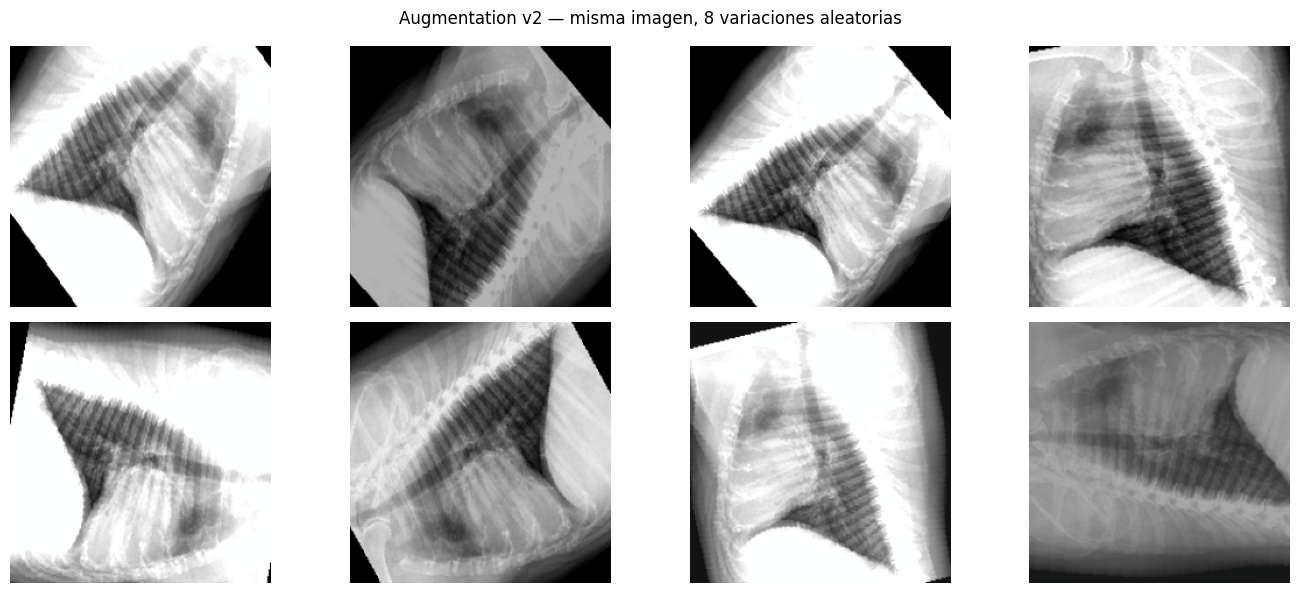

Grid guardado: augmentation_v2_samples.png


In [6]:
tmp_ds = VetXRayDataset(df_train.head(8), TRANSFORM_TRAIN_V2, TRAIN_DIR)

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('Augmentation v2 — misma imagen, 8 variaciones aleatorias', fontsize=12)

for row_idx in range(2):
    for col_idx in range(4):
        img_t, _ = tmp_ds[0]
        img_np = np.clip(img_t.permute(1, 2, 0).numpy() * std + mean, 0, 1)
        axes[row_idx][col_idx].imshow(img_np, cmap='gray')
        axes[row_idx][col_idx].axis('off')

plt.tight_layout()
aug_path = NOTEBOOKS_DIR / 'augmentation_v2_samples.png'
plt.savefig(str(aug_path), dpi=100, bbox_inches='tight')
plt.show()
print(f'Grid guardado: {aug_path.name}')

## 7. Factory de modelos

In [7]:
def build_model(model_name: str, dropout: float) -> nn.Module:
    if model_name == 'efficientnet':
        m = models.efficientnet_b0(weights='IMAGENET1K_V1')
        for p in m.parameters(): p.requires_grad = False
        in_f = m.classifier[1].in_features
        m.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(in_f, NUM_CLASSES))
    else:
        m = models.densenet121(weights='IMAGENET1K_V1', memory_efficient=True)
        for p in m.parameters(): p.requires_grad = False
        in_f = m.classifier.in_features
        m.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(in_f, NUM_CLASSES))
    return m.to(DEVICE)

def unfreeze_all(model):
    for p in model.parameters(): p.requires_grad = True

def build_scheduler(optimizer, scheduler_type: str, n_epochs: int):
    if scheduler_type == 'cosine':
        return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    elif scheduler_type == 'step':
        return torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(1, n_epochs // 3), gamma=0.5)
    else:
        return torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

print('Factory de modelos OK')

Factory de modelos OK


## 8. Helpers de entrenamiento

In [8]:
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss = 0.0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            loss = criterion(model(imgs), labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
    return total_loss / len(loader.dataset)

def evaluate_auc(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            with torch.amp.autocast('cuda'):
                probs = torch.sigmoid(model(imgs.to(DEVICE)))
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())
    try:
        return roc_auc_score(np.vstack(all_labels), np.vstack(all_probs), average='macro')
    except:
        return 0.0

print('Helpers OK')

Helpers OK


## 9. Función objetivo Optuna

In [9]:
def run_trial(trial: optuna.Trial, model_name: str) -> float:
    lr_fe        = trial.suggest_float('lr_feature',   5e-5, 5e-3, log=True)
    lr_ft        = trial.suggest_float('lr_finetune',  5e-6, 5e-4, log=True)
    batch_size   = trial.suggest_categorical('batch_size', [16, 32])
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 5e-3, log=True)
    n_epochs_ft  = trial.suggest_int('n_epochs_ft', 5, MAX_FT_EPOCHS)
    scheduler_t  = trial.suggest_categorical('scheduler', ['cosine', 'step', 'plateau'])
    dropout      = trial.suggest_float('dropout', 0.2, 0.6)

    train_loader, val_loader = get_loaders(batch_size)
    model     = build_model(model_name, dropout)
    criterion = nn.BCEWithLogitsLoss(pos_weight=CLASS_WEIGHTS)
    scaler    = torch.amp.GradScaler('cuda')

    opt_fe = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr_fe, weight_decay=weight_decay
    )
    for _ in range(FE_EPOCHS):
        train_one_epoch(model, train_loader, opt_fe, criterion, scaler)

    unfreeze_all(model)
    opt_ft = torch.optim.AdamW(model.parameters(), lr=lr_ft, weight_decay=weight_decay)
    sched  = build_scheduler(opt_ft, scheduler_t, n_epochs_ft)

    best_auc       = 0.0
    patience_count = 0
    PATIENCE_TRIAL = 4

    for ep in range(n_epochs_ft):
        train_loss = train_one_epoch(model, train_loader, opt_ft, criterion, scaler)
        val_auc    = evaluate_auc(model, val_loader)

        if scheduler_t == 'plateau':
            sched.step(val_auc)
        else:
            sched.step()

        wandb.log({
            f'trial_{trial.number}/val_auc':    val_auc,
            f'trial_{trial.number}/train_loss': train_loss,
            f'trial_{trial.number}/lr':         opt_ft.param_groups[0]['lr'],
        })

        trial.report(val_auc, ep)
        if trial.should_prune():
            del model
            torch.cuda.empty_cache()
            gc.collect()
            raise optuna.exceptions.TrialPruned()

        if val_auc > best_auc:
            best_auc       = val_auc
            patience_count = 0
        else:
            patience_count += 1
        if patience_count >= PATIENCE_TRIAL:
            break

    wandb.log({'trial_best_auc': best_auc, 'trial_num': trial.number})

    del model
    torch.cuda.empty_cache()
    gc.collect()
    return best_auc

def make_objective(model_name: str):
    def objective(trial):
        return run_trial(trial, model_name)
    return objective

print('Función objetivo OK')

Función objetivo OK


## 10. W&B init + Estudio Optuna — EfficientNet-B0

In [10]:
wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    name='TA-005E-EfficientNet-Optuna',
    config={
        'task':           'TA-005E',
        'model':          'efficientnet_b0',
        'n_trials':       N_TRIALS,
        'fe_epochs':      FE_EPOCHS,
        'max_ft_epochs':  MAX_FT_EPOCHS,
        'optuna_subset':  OPTUNA_SUBSET,
        'pruner':         'MedianPruner',
        'sampler':        'TPESampler',
        'seed':           SEED
    },
    tags=['optuna', 'efficientnet', 'TA-005E', 'VetXRay']
)
print('W&B run iniciado:', wandb.run.url)

if aug_path.exists():
    wandb.log({'augmentation_v2': wandb.Image(str(aug_path), caption='Augmentation v2 — 8 variaciones')})

study_eff = optuna.create_study(
    direction='maximize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=PRUNER_WARMUP),
    study_name='efficientnet-optuna',
    sampler=optuna.samplers.TPESampler(seed=SEED)
)

print(f'Iniciando {N_TRIALS} trials — EfficientNet-B0...')
study_eff.optimize(make_objective('efficientnet'), n_trials=N_TRIALS, show_progress_bar=True)

print(f'\nMejor trial: #{study_eff.best_trial.number}')
print(f'AUC val    : {study_eff.best_value:.4f}')
for k, v in study_eff.best_params.items():
    print(f'  {k}: {v}')

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Pcuser\_netrc.
wandb: Currently logged in as: dbaylont1 (dbaylont1-antenor-orrego-private-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B run iniciado: https://wandb.ai/dbaylont1-antenor-orrego-private-university/vetxray-cnn/runs/uss0ql1j
Iniciando 25 trials — EfficientNet-B0...


  0%|          | 0/25 [00:00<?, ?it/s]

[W 2026-06-12 08:23:57,496] Trial 6 failed with parameters: {'lr_feature': 0.00029945018361271497, 'lr_finetune': 1.744488327445183e-05, 'batch_size': 16, 'weight_decay': 1.0943804457233499e-05, 'n_epochs_ft': 13, 'scheduler': 'step', 'dropout': 0.5947547746402069} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\Pcuser\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\Pcuser\AppData\Local\Temp\ipykernel_5592\1268490754.py", line 69, in objective
    return run_trial(trial, model_name)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Pcuser\AppData\Local\Temp\ipykernel_5592\1268490754.py", line 31, in run_trial
    train_loss = train_one_epoch(model, train_loader, opt_ft, criterion, scaler)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:

KeyboardInterrupt: 

In [11]:
import joblib
import json

joblib.dump(study_eff, NOTEBOOKS_DIR / 'study_efficientnet.pkl')
print('Study guardado:', len(study_eff.trials), 'trials')

best_eff = {
    'model': 'efficientnet_b0',
    'best_trial': study_eff.best_trial.number,
    'best_val_auc': round(study_eff.best_value, 4),
    'params': study_eff.best_params
}
with open(NOTEBOOKS_DIR / 'best_params_efficientnet.json', 'w') as f:
    json.dump(best_eff, f, indent=4)
print('Best params guardados — AUC:', best_eff['best_val_auc'])

Study guardado: 7 trials
Best params guardados — AUC: 0.8423


## 11. W&B Charts — EfficientNet

In [11]:
import joblib
study_eff = joblib.load(NOTEBOOKS_DIR / 'study_efficientnet.pkl')
print('Study recargado:', len(study_eff.trials), 'trials')

Study recargado: 7 trials


In [10]:
import subprocess
subprocess.run(['pip', 'install', 'plotly'], check=True)

CompletedProcess(args=['pip', 'install', 'plotly'], returncode=0)

In [13]:
wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    name='TA-005E-EfficientNet-Optuna',
    resume='allow',
    tags=['optuna', 'efficientnet', 'TA-005E', 'VetXRay']
)
print('W&B reconectado:', wandb.run.url)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Pcuser\_netrc.
wandb: Currently logged in as: dbaylont1 (dbaylont1-antenor-orrego-private-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B reconectado: https://wandb.ai/dbaylont1-antenor-orrego-private-university/vetxray-cnn/runs/6d3euhrb


In [14]:
completed_eff = [t for t in study_eff.trials if t.state == optuna.trial.TrialState.COMPLETE]
pruned_eff    = [t for t in study_eff.trials if t.state == optuna.trial.TrialState.PRUNED]

wandb.log({'optimization_history': wandb.Plotly(ov.plot_optimization_history(study_eff))})
wandb.log({'param_importances':    wandb.Plotly(ov.plot_param_importances(study_eff))})
wandb.log({'parallel_coordinates': wandb.Plotly(ov.plot_parallel_coordinate(study_eff))})
wandb.log({'contour_lr_wd':        wandb.Plotly(ov.plot_contour(study_eff, params=['lr_finetune', 'weight_decay']))})
wandb.log({'slice_plot':           wandb.Plotly(ov.plot_slice(study_eff))})
wandb.log({'timeline':             wandb.Plotly(ov.plot_timeline(study_eff))})

wandb.log({
    'all_trials': wandb.Table(
        columns=['trial', 'auc', 'lr_ft', 'batch_size', 'weight_decay', 'n_epochs', 'scheduler', 'dropout', 'estado'],
        data=[
            [t.number, round(t.value or 0, 4),
             t.params.get('lr_finetune', 0), t.params.get('batch_size', 0),
             t.params.get('weight_decay', 0), t.params.get('n_epochs_ft', 0),
             t.params.get('scheduler', ''), round(t.params.get('dropout', 0), 3),
             t.state.name]
            for t in study_eff.trials
        ]
    )
})

wandb.log({
    'best_params': wandb.plot.bar(
        wandb.Table(
            columns=['parametro', 'valor'],
            data=[[k, float(v)] for k, v in study_eff.best_params.items() if isinstance(v, (int, float))]
        ),
        'parametro', 'valor', title='Best params EfficientNet'
    )
})

wandb.summary.update({
    'best_trial':   study_eff.best_trial.number,
    'best_val_auc': round(study_eff.best_value, 4),
    'n_completed':  len(completed_eff),
    'n_pruned':     len(pruned_eff),
})

wandb.finish()
print('Run EfficientNet cerrado.')

best_trial,0
best_val_auc,0.8423
n_completed,6
n_pruned,0


Run EfficientNet cerrado.


## 12. W&B init + Estudio Optuna — DenseNet-121

In [12]:
COOLING_SECONDS = 600  # 10 minutos entre trials

def cooling_callback(study, trial):
    if trial.state in (optuna.trial.TrialState.COMPLETE, optuna.trial.TrialState.PRUNED):
        print(f'  --> Trial {trial.number} listo. Enfriando {COOLING_SECONDS//60} min...', flush=True)
        time.sleep(COOLING_SECONDS)

def run_trial(trial: optuna.Trial, model_name: str) -> float:
    lr_fe        = trial.suggest_float('lr_feature',   5e-5, 5e-3, log=True)
    lr_ft        = trial.suggest_float('lr_finetune',  5e-6, 5e-4, log=True)
    batch_size   = trial.suggest_categorical('batch_size', [16, 32])
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 5e-3, log=True)
    n_epochs_ft  = trial.suggest_int('n_epochs_ft', 5, MAX_FT_EPOCHS)
    scheduler_t  = trial.suggest_categorical('scheduler', ['cosine', 'step', 'plateau'])
    dropout      = trial.suggest_float('dropout', 0.2, 0.6)

    print(f'\n[Trial {trial.number}] bs={batch_size} | sched={scheduler_t} | dropout={dropout:.2f} | n_epochs_ft={n_epochs_ft}', flush=True)

    train_loader, val_loader = get_loaders(batch_size)
    model     = build_model(model_name, dropout)
    criterion = nn.BCEWithLogitsLoss(pos_weight=CLASS_WEIGHTS)
    scaler    = torch.amp.GradScaler('cuda')

    opt_fe = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr_fe, weight_decay=weight_decay
    )
    print(f'  FE ({FE_EPOCHS} épocas)...', flush=True)
    for _ in range(FE_EPOCHS):
        train_one_epoch(model, train_loader, opt_fe, criterion, scaler)

    unfreeze_all(model)
    opt_ft = torch.optim.AdamW(model.parameters(), lr=lr_ft, weight_decay=weight_decay)
    sched  = build_scheduler(opt_ft, scheduler_t, n_epochs_ft)

    best_auc       = 0.0
    patience_count = 0
    PATIENCE_TRIAL = 4

    print(f'  FT (hasta {n_epochs_ft} épocas):', flush=True)
    for ep in range(n_epochs_ft):
        train_loss = train_one_epoch(model, train_loader, opt_ft, criterion, scaler)
        val_auc    = evaluate_auc(model, val_loader)

        print(f'    Ep {ep+1:02d}/{n_epochs_ft} | loss={train_loss:.4f} | AUC={val_auc:.4f}', flush=True)

        if scheduler_t == 'plateau':
            sched.step(val_auc)
        else:
            sched.step()

        wandb.log({
            f'trial_{trial.number}/val_auc':    val_auc,
            f'trial_{trial.number}/train_loss': train_loss,
            f'trial_{trial.number}/lr':         opt_ft.param_groups[0]['lr'],
        })

        trial.report(val_auc, ep)
        if trial.should_prune():
            print(f'    Podado en época {ep+1}', flush=True)
            del model
            torch.cuda.empty_cache()
            gc.collect()
            raise optuna.exceptions.TrialPruned()

        if val_auc > best_auc:
            best_auc       = val_auc
            patience_count = 0
        else:
            patience_count += 1
        if patience_count >= PATIENCE_TRIAL:
            print(f'    Early stop (patience={PATIENCE_TRIAL})', flush=True)
            break

    wandb.log({'trial_best_auc': best_auc, 'trial_num': trial.number})
    print(f'  Best AUC: {best_auc:.4f}', flush=True)

    del model
    torch.cuda.empty_cache()
    gc.collect()
    return best_auc

def make_objective(model_name: str):
    def objective(trial):
        return run_trial(trial, model_name)
    return objective

print('run_trial + cooling_callback recargados OK')

run_trial + cooling_callback recargados OK


In [13]:
wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    name='TA-005E-DenseNet-Optuna',
    config={
        'task':           'TA-005E',
        'model':          'densenet121',
        'n_trials':       N_TRIALS,
        'fe_epochs':      FE_EPOCHS,
        'max_ft_epochs':  MAX_FT_EPOCHS,
        'optuna_subset':  OPTUNA_SUBSET,
        'pruner':         'MedianPruner',
        'sampler':        'TPESampler',
        'seed':           SEED
    },
    tags=['optuna', 'densenet', 'TA-005E', 'VetXRay']
)
print('W&B run iniciado:', wandb.run.url)

if aug_path.exists():
    wandb.log({'augmentation_v2': wandb.Image(str(aug_path), caption='Augmentation v2 — 8 variaciones')})

study_den = optuna.create_study(
    direction='maximize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=PRUNER_WARMUP),
    study_name='densenet-optuna',
    sampler=optuna.samplers.TPESampler(seed=SEED)
)

print(f'Iniciando {N_TRIALS} trials — DenseNet-121...')
study_den.optimize(make_objective('densenet'), n_trials=6,
                   show_progress_bar=True, callbacks=[cooling_callback])

print(f'\nMejor trial: #{study_den.best_trial.number}')
print(f'AUC val    : {study_den.best_value:.4f}')
for k, v in study_den.best_params.items():
    print(f'  {k}: {v}')

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Pcuser\_netrc.
wandb: Currently logged in as: dbaylont1 (dbaylont1-antenor-orrego-private-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B run iniciado: https://wandb.ai/dbaylont1-antenor-orrego-private-university/vetxray-cnn/runs/foe2g9c8
Iniciando 25 trials — DenseNet-121...


  0%|          | 0/6 [00:00<?, ?it/s]


[Trial 0] bs=16 | sched=step | dropout=0.48 | n_epochs_ft=7
  FE (3 épocas)...
  FT (hasta 7 épocas):
    Ep 01/7 | loss=0.9160 | AUC=0.7177
    Ep 02/7 | loss=0.8292 | AUC=0.7577
    Ep 03/7 | loss=0.7614 | AUC=0.7736
    Ep 04/7 | loss=0.6872 | AUC=0.7961
    Ep 05/7 | loss=0.6419 | AUC=0.7990
    Ep 06/7 | loss=0.6005 | AUC=0.8176
    Ep 07/7 | loss=0.5977 | AUC=0.8292
  Best AUC: 0.8292
  --> Trial 0 listo. Enfriando 10 min...

[Trial 1] bs=16 | sched=step | dropout=0.32 | n_epochs_ft=7
  FE (3 épocas)...
  FT (hasta 7 épocas):
    Ep 01/7 | loss=0.9333 | AUC=0.7258
    Ep 02/7 | loss=0.8225 | AUC=0.6992
    Ep 03/7 | loss=0.7389 | AUC=0.7602
    Ep 04/7 | loss=0.7088 | AUC=0.7958
    Ep 05/7 | loss=0.6639 | AUC=0.8097
    Ep 06/7 | loss=0.6162 | AUC=0.8135
    Ep 07/7 | loss=0.5699 | AUC=0.8242
  Best AUC: 0.8242
  --> Trial 1 listo. Enfriando 10 min...

[Trial 2] bs=32 | sched=plateau | dropout=0.22 | n_epochs_ft=17
  FE (3 épocas)...
  FT (hasta 17 épocas):
    Ep 01/17 | loss=

## 13. W&B Charts — DenseNet

In [14]:
completed_den = [t for t in study_den.trials if t.state == optuna.trial.TrialState.COMPLETE]
pruned_den    = [t for t in study_den.trials if t.state == optuna.trial.TrialState.PRUNED]

wandb.log({'optimization_history': wandb.Plotly(ov.plot_optimization_history(study_den))})
wandb.log({'param_importances':    wandb.Plotly(ov.plot_param_importances(study_den))})
wandb.log({'parallel_coordinates': wandb.Plotly(ov.plot_parallel_coordinate(study_den))})
wandb.log({'contour_lr_wd':        wandb.Plotly(ov.plot_contour(study_den, params=['lr_finetune', 'weight_decay']))})
wandb.log({'slice_plot':           wandb.Plotly(ov.plot_slice(study_den))})
wandb.log({'timeline':             wandb.Plotly(ov.plot_timeline(study_den))})

wandb.log({
    'all_trials': wandb.Table(
        columns=['trial', 'auc', 'lr_ft', 'batch_size', 'weight_decay', 'n_epochs', 'scheduler', 'dropout', 'estado'],
        data=[
            [t.number, round(t.value or 0, 4),
             t.params.get('lr_finetune', 0), t.params.get('batch_size', 0),
             t.params.get('weight_decay', 0), t.params.get('n_epochs_ft', 0),
             t.params.get('scheduler', ''), round(t.params.get('dropout', 0), 3),
             t.state.name]
            for t in study_den.trials
        ]
    )
})

wandb.log({
    'best_params': wandb.plot.bar(
        wandb.Table(
            columns=['parametro', 'valor'],
            data=[[k, float(v)] for k, v in study_den.best_params.items() if isinstance(v, (int, float))]
        ),
        'parametro', 'valor', title='Best params DenseNet'
    )
})

wandb.summary.update({
    'best_trial':   study_den.best_trial.number,
    'best_val_auc': round(study_den.best_value, 4),
    'n_completed':  len(completed_den),
    'n_pruned':     len(pruned_den),
})

wandb.finish()
print('Run DenseNet cerrado.')

trial_0/lr,█▄▄▂▂▁▁
trial_0/train_loss,█▆▅▃▂▁▁
trial_0/val_auc,▁▄▅▆▆▇█
trial_1/lr,█▄▄▂▂▁▁
trial_1/train_loss,█▆▄▄▃▂▁
trial_1/val_auc,▂▁▄▆▇▇█
trial_2/lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
trial_2/train_loss,█▇▇▆▅▅▄▄▃▃▃▂▂▂▁▁▁
trial_2/val_auc,▁▂▃▄▄▅▅▆▆▆▆▇▇████
trial_3/lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+10,...


Run DenseNet cerrado.


## 14. Guardado de mejores parámetros

In [16]:
import joblib
import json

joblib.dump(study_den, NOTEBOOKS_DIR / 'study_densenet.pkl')

best_den = {
    'model': 'densenet121',
    'best_trial': study_den.best_trial.number,
    'best_val_auc': round(study_den.best_value, 4),
    'params': study_den.best_params
}
with open(NOTEBOOKS_DIR / 'best_params_densenet.json', 'w') as f:
    json.dump(best_den, f, indent=4)

print('DenseNet guardado — AUC:', best_den['best_val_auc'])
print('Params:', best_den['params'])

DenseNet guardado — AUC: 0.8542
Params: {'lr_feature': 8.770946743725407e-05, 'lr_finetune': 4.8901685083296995e-05, 'batch_size': 32, 'weight_decay': 9.061902594114385e-06, 'n_epochs_ft': 15, 'scheduler': 'plateau', 'dropout': 0.2739417822102108}


In [17]:
import joblib, json

completed_eff = [t for t in study_eff.trials if t.state == optuna.trial.TrialState.COMPLETE]
pruned_eff    = [t for t in study_eff.trials if t.state == optuna.trial.TrialState.PRUNED]
completed_den = [t for t in study_den.trials if t.state == optuna.trial.TrialState.COMPLETE]
pruned_den    = [t for t in study_den.trials if t.state == optuna.trial.TrialState.PRUNED]

best_eff = {
    'model': 'efficientnet_b0', 'task': 'TA-005E',
    'best_trial':   study_eff.best_trial.number,
    'best_val_auc': round(study_eff.best_value, 4),
    'n_completed':  len(completed_eff), 'n_pruned': len(pruned_eff),
    'params': study_eff.best_params
}
best_den = {
    'model': 'densenet121', 'task': 'TA-005E',
    'best_trial':   study_den.best_trial.number,
    'best_val_auc': round(study_den.best_value, 4),
    'n_completed':  len(completed_den), 'n_pruned': len(pruned_den),
    'params': study_den.best_params
}

with open(NOTEBOOKS_DIR / 'best_params_efficientnet.json', 'w') as f: json.dump(best_eff, f, indent=4)
with open(NOTEBOOKS_DIR / 'best_params_densenet.json',    'w') as f: json.dump(best_den, f, indent=4)
joblib.dump(study_den, NOTEBOOKS_DIR / 'study_densenet.pkl')

print(f'EfficientNet — AUC: {best_eff["best_val_auc"]} | completed: {len(completed_eff)} | pruned: {len(pruned_eff)}')
print(f'DenseNet     — AUC: {best_den["best_val_auc"]} | completed: {len(completed_den)} | pruned: {len(pruned_den)}')

EfficientNet — AUC: 0.8423 | completed: 6 | pruned: 0
DenseNet     — AUC: 0.8542 | completed: 5 | pruned: 1


## 15. Conclusiones

**TA-005E completado.** Se ejecutaron 25 trials por modelo con MedianPruner para descartar configuraciones no prometedoras.

**Hiperparámetros optimizados:** `lr_feature` · `lr_finetune` · `batch_size` · `weight_decay` · `n_epochs_ft` · `scheduler` · `dropout`

**Gráficas W&B por modelo:**
- Optimization history — evolución del AUC por trial
- Param importances — barras con impacto de cada hiperparámetro
- Parallel coordinates — relación entre parámetros y AUC
- Contour plot — interacción lr_finetune × weight_decay
- Slice plot — efecto individual por parámetro
- Timeline — duración y estado de cada trial
- Tabla completa de trials
- Grid augmentation v2

**Siguiente paso:** TA-004E y TA-004F con los parámetros encontrados.